In [1]:
import utils
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('display.max_rows', None)

# Exclusion criteria
- Check only the last two blocks
- cutoff for congruent = 60%
- cutoff for incongruent = 100% - congruent + 10%

In [2]:
# Preparation
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers
raw_output_path = '/Volumes/project/3025011.02/raw/'
unique_subject_ids = [25]
unique_sessions = [1]
use_second_block = False

# Load and combine the datasets
combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions)

['/Volumes/project/3025011.02/raw/sub-029/ses-mri01/beh/behavioural_output_sub-029_session-01_dummy_2025-07-07_11-48-21.csv']
These participants will be excluded: {'sub-016_session-04', 'sub-011_session-03', 'sub-011_session-01', 'sub-011_session-04', 'sub-011_session-02'}

     stimuli_type  probability_condition   congruency
0               1                     50    undefined
1               2                     50    undefined
2               1                     50    undefined
3               2                     50    undefined
4               1                     50    undefined
5               2                     50    undefined
6               2                     50    undefined
7               1                     50    undefined
8               1                     80    congruent
9               2                     20    congruent
10              1                     80    congruent
11              2                     20    congruent
12              1      

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/import_functions.py:479: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe['objectively_correct_boolean'] = dataframe['objectively_correct'].replace(mapping)


# Remove everything but the last two blocks

In [3]:
# Create a helper column that increments whenever the value changes.
# This assigns a unique group number to each contiguous block.
last_block_stimulus_1 = combined_results_dataframe[combined_results_dataframe['stimuli_type'] == 1]
last_block_stimulus_2 = combined_results_dataframe[combined_results_dataframe['stimuli_type'] == 2]
last_block_stimulus_1['group'] = (last_block_stimulus_1['volatility'] != last_block_stimulus_1['volatility'].shift()).cumsum()
last_block_stimulus_2['group'] = (last_block_stimulus_2['volatility'] != last_block_stimulus_2['volatility'].shift()).cumsum()

# Get the top two values from the "group" column
unique_groups = last_block_stimulus_1['group'].unique()
if use_second_block:
    top_two = sorted(unique_groups, reverse=True)[2:4]
else:
    top_two = sorted(unique_groups, reverse=True)[:2]
print(top_two)
# Filter the DataFrame to include only rows with these top two values
last_block_stimulus_1 = last_block_stimulus_1[last_block_stimulus_1['group'].isin(top_two)]
# Get the top two values from the "group" column
unique_groups = last_block_stimulus_2['group'].unique()
if use_second_block:
    top_two = sorted(unique_groups, reverse=True)[2:4]
else:
    top_two = sorted(unique_groups, reverse=True)[:2]
print(top_two)
# Filter the DataFrame to include only rows with these top two values
last_block_stimulus_2 = last_block_stimulus_2[last_block_stimulus_2['group'].isin(top_two)]

frames = [last_block_stimulus_1, last_block_stimulus_2]

last_block_stimulus = pd.concat(frames)

last_blocks_results = last_block_stimulus.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
# Reset the index
last_blocks_results.reset_index(drop=True, inplace=True)

# Filter to keep only rows that belong to these last blocks
print(last_blocks_results[['trial','stimuli_type','volatility','group']])
last_blocks_results.drop(columns='group', inplace=True)

[7, 6]
[7, 6]
     trial  stimuli_type volatility  group
0      468             1     stable      6
1      469             1     stable      6
2      473             1     stable      6
3      474             1     stable      6
4      476             1     stable      6
5      477             1     stable      6
6      480             1     stable      6
7      482             1     stable      6
8      484             1     stable      6
9      487             1     stable      6
10     488             1     stable      6
11     491             1     stable      6
12     492             1     stable      6
13     495             1     stable      6
14     496             1     stable      6
15     498             1     stable      6
16     501             1     stable      6
17     503             1     stable      6
18     507             1     stable      6
19     508             1     stable      6
20     509             1     stable      6
21     510             1     stable     

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3745/4119392886.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_block_stimulus_1['group'] = (last_block_stimulus_1['volatility'] != last_block_stimulus_1['volatility'].shift()).cumsum()
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3745/4119392886.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_block_stimulus_2['group'] = (last_block_stimulus_2['volatility'] != last_block_stimulus_2['volatility'].shift()).cumsum()


In [4]:
# Create new plots with different intervals that also contain the 50% trials
print(last_blocks_results)
unique_stimuli_types = last_blocks_results['stimuli_type'].unique()
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
session_name = 'session'
unique_group_types = last_blocks_results[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(last_blocks_results,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
print(all_reversals_dataframe)

     trial  emotional_cue_time response objectively_correct  \
0      468        1.751884e+09       up                True   
1      469        1.751884e+09       up                True   
2      473        1.751884e+09       up                True   
3      474        1.751884e+09       up                True   
4      476        1.751884e+09       up                True   
5      477        1.751884e+09       up                True   
6      480        1.751884e+09       up                True   
7      482        1.751884e+09       up                True   
8      484        1.751884e+09       up                True   
9      487        1.751884e+09       up                True   
10     488        1.751884e+09       up                True   
11     491        1.751884e+09       up                True   
12     492        1.751884e+09       up                True   
13     495        1.751884e+09       up                True   
14     496        1.751884e+09       up                

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:679: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['reversal'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_f

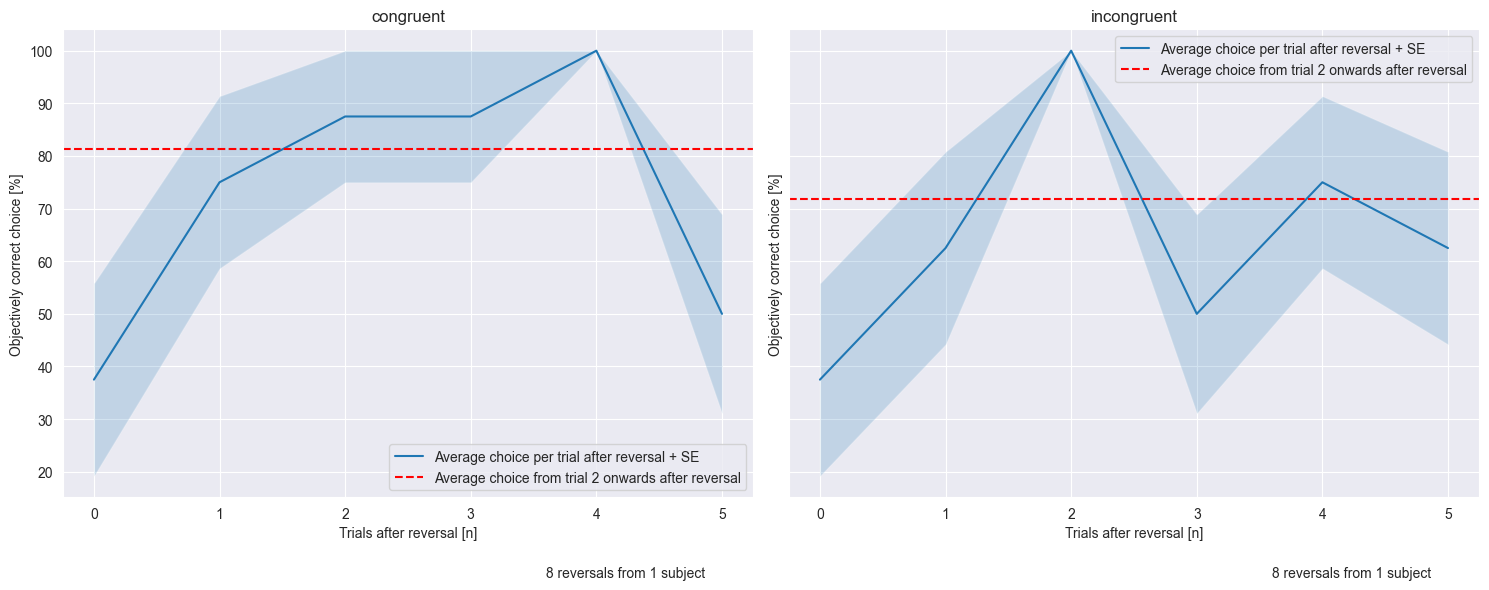

In [5]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_reversals_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial after reversal + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after reversal')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials after reversal [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        axs[i].text(3.6, 0, f'{group_counts[congruency_type]} reversals from {subject_counts} subject', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

plt.tight_layout()
plt.show()

Mean score for the congruent condition 81.48148148148148% and incongruent condition 66.66666666666666% fall within the cutoffs.
Include the participant.



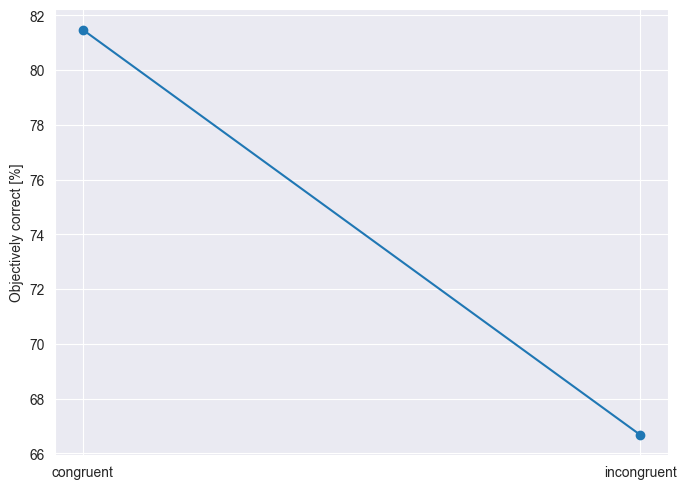

In [6]:
# Remove first trials after a reversal
last_blocks_results['time_since_reversal'] = (
    last_blocks_results.groupby((last_blocks_results['probability_condition'] != last_blocks_results['probability_condition'].shift()).cumsum())
      .cumcount()
)
last_blocks_results = last_blocks_results[last_blocks_results['time_since_reversal'] != 0]

# Splitting the dataframe into the two congruent blocks
dataframe_1 = last_blocks_results[last_blocks_results['congruency'] == 'congruent']
dataframe_1 = dataframe_1.groupby(['subject_id', 'session'])['objectively_correct_boolean'].mean().reset_index()
list_1 = dataframe_1['objectively_correct_boolean'].dropna().tolist()
congruent_score = list_1[0] * 100
dataframe_2 = last_blocks_results[last_blocks_results['congruency'] == 'incongruent']
dataframe_2 = dataframe_2.groupby(['subject_id', 'session'])['objectively_correct_boolean'].mean().reset_index()
list_2 = dataframe_2['objectively_correct_boolean'].dropna().tolist()
incongruent_score = list_2[0] * 100

# Plot data
fig, ax = plt.subplots(figsize=(7, 5))
subject_data = pd.DataFrame.from_dict({'x': [1, 2], 'data': [congruent_score, incongruent_score]})
plt.plot(subject_data['x'], subject_data['data'], marker='o')

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['congruent', 'incongruent'])  # Set text labels.
plt.ylabel('Objectively correct [%]')
plot_name = 'all_trials_objective_performance_congruency'

# Determine whether participant meets cutoff criteria
cutoff_opposite = 100 - congruent_score + 10
if congruent_score < 60:
    print(f'Mean score for the congruent condition {congruent_score:.2f}% is below the 60% threshold.\n'
          'Exclude the participant.\n')
    participant_excluded = True
elif incongruent_score < 40:
    print(f'Mean score for the incongruent condition {incongruent_score:.2f}% is below the 40% threshold.\n'
          'Exclude the participant.\n')
    participant_excluded = True
elif incongruent_score < cutoff_opposite:
    print(f'Mean score for the incongruent condition {incongruent_score:.2f}% is below the threshold 100 - congruent score + 10 ({cutoff_opposite:.2f}%).\n'
          'Exclude the participant.\n')
    participant_excluded = True
else:
    print(f'Mean score for the congruent condition {congruent_score}% and incongruent condition {incongruent_score}% fall within the cutoffs.\n'
    'Include the participant.\n')
    participant_excluded = False

# Show plot
plt.tight_layout()
plt.show()

# Responses over the entire experiment

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:207: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe[new_column] = dataframe[old_column].replace(mapping)


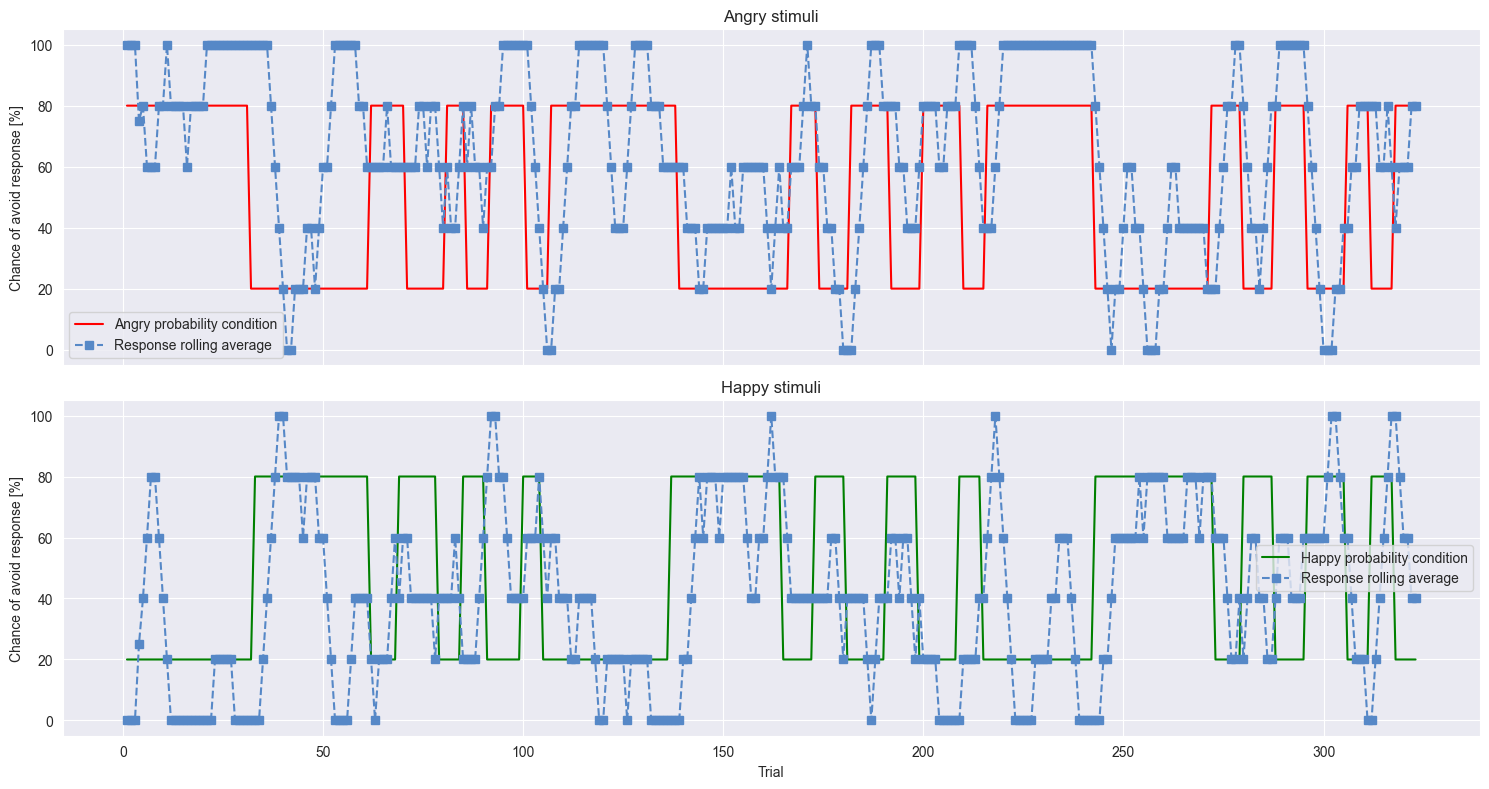

In [7]:
# Jitter vertically to make the lines easier to read when overlapping
dataframe = combined_results_dataframe.dropna(subset=['response'])
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'])
dataframe['trial_separated'] = (
    dataframe
    .groupby(['subject_id', 'session', 'stimuli_type'])
    .cumcount()
    + 1
)
dataframe = utils.analysis_functions.replace_strings_with_integers(dataframe,
                                                                                    {'up': 100, 'down': 0},
                                                                                    'response',
                                                                                    'response_int')
dataframe['response_rolling_average'] = (
    dataframe
    .groupby('stimuli_type')['response_int']
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

stimuli_list = ['Angry', 'Happy']
colour_list = ['red', 'green']

stim_types = dataframe['stimuli_type'].unique()
n_types = len(stim_types)

# create one subplot per stimuli_type
fig, axes = plt.subplots(n_types, 1,
                         figsize=(15, 4 * n_types),
                         sharex=True)

# if there's only one type, axes is not a list
if n_types == 1:
    axes = [axes]

for ax, stim in zip(axes, stim_types):
    sub = dataframe[dataframe['stimuli_type'] == stim]
    ax.plot(sub['trial_separated'], sub['probability_condition'], linestyle='-',
            label=f'{stimuli_list[stim-1]} probability condition', color=colour_list[stim-1])
    ax.plot(sub['trial_separated'], sub['response_rolling_average'],
            marker='s', linestyle='--',
            label='Response rolling average', color='#5688C7')
    ax.set_title(f'{stimuli_list[stim-1]} stimuli')
    ax.set_ylabel('Chance of avoid response [%]')
    ax.legend(loc='best')

# common x-axis label
axes[-1].set_xlabel('Trial')

plt.tight_layout()
plt.show()

# Reaction time check

0 out of 646 trials are non-response trials
So, 0.00% of the trials are non-response trials
Include the participant.

Participant locked the joystick in 0 out of 646 trials
That's 0.00% of the trials
Include the participant.



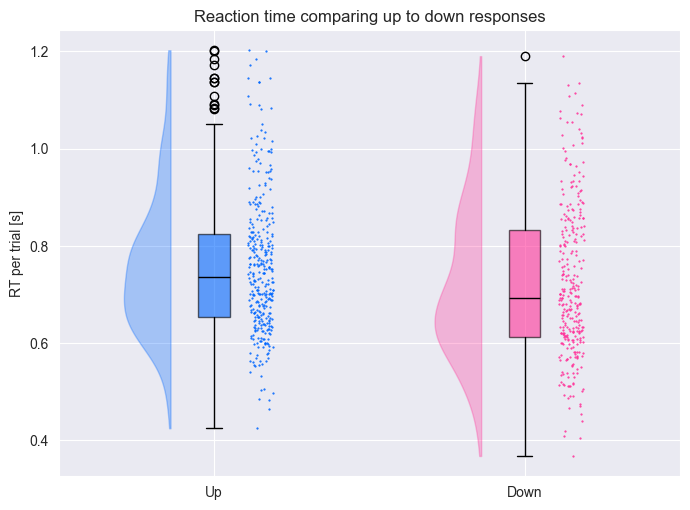

In [8]:
# Print percentage of non-response trials
non_response_trials = combined_results_dataframe[combined_results_dataframe['response'].isna()]
percentage_responses = len(non_response_trials)/len(combined_results_dataframe)*100

if percentage_responses > 10:
    print(f'{len(non_response_trials)} out of {len(combined_results_dataframe)} trials are non-response trials\n'
      f'So, {percentage_responses:.2f}% of the trials are non-response trials\n'
      'This means that the participant responded in less than 90% of the trials.\n'
          'Exclude the participant.\n')
    participant_excluded = True
else:
    print(f'{len(non_response_trials)} out of {len(combined_results_dataframe)} trials are non-response trials\n'
      f'So, {percentage_responses:.2f}% of the trials are non-response trials\n'
          'Include the participant.\n')
    participant_excluded = False

joystick_locked_trials = combined_results_dataframe[combined_results_dataframe['RT_s'] < 0.05]
percentage_joystick_locked = len(joystick_locked_trials)/len(combined_results_dataframe)*100

if percentage_joystick_locked > 10:
    print(f'Participant locked the joystick in {len(joystick_locked_trials)} out of {len(combined_results_dataframe)} trials\n'
      f"That's {percentage_joystick_locked:.2f}% of the trials\n"
      'This means that the participant locked the joystick in more than 10% of the trials.\n'
          'Exclude the participant.\n')
    participant_excluded = True
else:
    print(f'Participant locked the joystick in {len(joystick_locked_trials)} out of {len(combined_results_dataframe)} trials\n'
      f"That's {percentage_joystick_locked:.2f}% of the trials\n"
          'Include the participant.\n')
    participant_excluded = False

# Plot reaction time
happy_dataframe = combined_results_dataframe[combined_results_dataframe['response'] == 'up']
happy_list = happy_dataframe['RT_s'].dropna().tolist()
angry_dataframe = combined_results_dataframe[combined_results_dataframe['response'] == 'down']
angry_list = angry_dataframe['RT_s'].dropna().tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#0066ff', '#ff3399']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Up', 'Down'])  # Set text labels.
plt.ylabel('RT per trial [s]')
plot_name = 'Reaction time comparing up to down responses'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.show()

In [9]:
if participant_excluded:
    raise Exception('Participant excluded on behavioural criteria')

# Adjust simulations
- Check MI Skin and Brain to see if it's below 1.9
- Check CEM43 skin and brain to see if it's below 0.25
- Check if maxT skin and brain exceeds 39 degrees Celsius

In [10]:
simulation_directory = f'/Volumes/project/3025011.02/TUS_simulations/planning/'
stimulation_limits_exceeded = False

stimulation_output_full_filenames_1 = os.path.join(simulation_directory, '**', '*layered_output_table_target_1*.csv')
stimulation_output_full_filenames_2 = os.path.join(simulation_directory, '**', '*layered_output_table_target_2*.csv')
stimulation_output_full_filenames_3 = os.path.join(simulation_directory, '**', '*layered_output_table_target_3*.csv')

simulation_output_full_filenames = glob.glob(stimulation_output_full_filenames_1, recursive=True) + glob.glob(stimulation_output_full_filenames_2, recursive=True) + glob.glob(stimulation_output_full_filenames_3, recursive=True)

simulation_output_full_filenames = [s for s in simulation_output_full_filenames if f'sub-{unique_subject_ids[0]:03}' in s]
if not simulation_output_full_filenames:
    raise Exception('No simulations found')
simulation_output_full_filenames.sort()
print(simulation_output_full_filenames)

['/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-029/sub-029_layered_output_table_target_1_1_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_2/sub-029/sub-029_layered_output_table_target_1_2_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_3/sub-029/sub-029_layered_output_table_target_1_3_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_4/sub-029/sub-029_layered_output_table_target_1_4_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_5/sub-029/sub-029_layered_output_table_target_1_5_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-029/sub-029_layered_output_table_target_1_6_dc20_strength_1.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_1/sub-029/sub-029_layered_output_table_target_2_1_dc20_strength_3.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/

### Check if target names are missing

In [11]:
expected = [f"target_{i}_{j}"
            for i in range(1, 4)
            for j in range(1, 7)]

# find which expected names are missing
missing = [t for t in expected
           if not any(t in filename for filename in simulation_output_full_filenames)]

if missing:
    print("Missing target names:")
    for name in missing:
        print("  -", name)
else:
    print("All target names 1_1 through 3_6 are present.")

All target names 1_1 through 3_6 are present.


In [12]:
# List to hold individual dataframes
list_of_dataframes = []

# Process each CSV file
for simulation_output_full_filename in simulation_output_full_filenames:
    # Extract the filename (without the path)
    stimulation_output_filename = os.path.basename(simulation_output_full_filename)
    # Remove the '.csv' extension
    stimulation_output_filename_without_extension = os.path.splitext(stimulation_output_filename)[0]

    # Split the filename by underscores
    stimulation_output_filename_parts = stimulation_output_filename_without_extension.split('_')

    # Extract the subject_id and target from the filename parts
    subject_id = stimulation_output_filename_parts[0]
    target = '_'.join(stimulation_output_filename_parts[4:7])

    # Read the CSV file (assuming it contains one row)
    try:
        df = pd.read_csv(simulation_output_full_filename)
    except Exception as e:
        print(f"Error reading {simulation_output_full_filename}: {e}")
        continue  # Skip this file if there's an error

    # Add the intensity and duty cycle based on the filename parts
    df['target'] = target
    if 'target_3' in target:
        df['intensity'] = 'strength_1'
        df['duty_cycle'] = 'dc20'
    else:
        duty_cycle = stimulation_output_filename_parts[7]
        intensity = '_'.join(stimulation_output_filename_parts[8:10])
        df['intensity'] = intensity
        df['duty_cycle'] = duty_cycle

    # Append the dataframe to the list
    list_of_dataframes.append(df)

# Combine all dataframes into one
if list_of_dataframes:
    stimulation_output = pd.concat(list_of_dataframes, ignore_index=True)
    print(stimulation_output)
else:
    raise Exception("No CSV files were found or processed.")

    subject_id  max_Isppa  max_Isppa_after_exit_plane  real_focal_distance  \
0           29   10.71090                   10.710900            29.008619   
1           29   11.83880                   10.482660             9.500000   
2           29   10.71090                   10.710900            29.008619   
3           29   11.83880                   10.482660             9.500000   
4           29   10.71090                   10.710900            29.008619   
5           29   11.83880                   10.482660             9.500000   
6           29   21.94766                   21.947660            13.500000   
7           29   28.14075                   28.140750            14.008926   
8           29   23.52731                   23.527310            18.013884   
9           29   25.12610                   25.126100            14.008926   
10          29   23.58545                   23.585450            14.508618   
11          29   22.59638                   22.596380           

In [13]:
# Reorder columns
column_indices = list(range(stimulation_output.shape[1]))
reordered_column_indices = [column_indices[0]] + column_indices[-3:] + column_indices[1:-3]
stimulation_output = stimulation_output.iloc[:, reordered_column_indices]
stimulation_output.sort_values(by=['subject_id', 'target', 'intensity', 'duty_cycle'], inplace=True)
stimulation_output.reset_index(drop=True, inplace=True)
stimulation_output['CEM43_brain_skin'] = stimulation_output[['CEM43_brain', 'CEM43_skin']].max(axis=1)
# Replace values to improve readability
stimulation_output['duty_cycle'] = stimulation_output['duty_cycle'].map({'dc10': '10%', 'dc15': '15%', 'dc20': '20%'})
stimulation_output['intensity'] = stimulation_output['intensity'].map({'strength_1': '35', 'strength_2': '63', 'strength_3': '81', 'strength_4': '110'})
# Now drop some columns
stimulation_output.drop(
    ['real_focal_distance','Ix_brain', 'Iy_brain','Iz_brain',
     'max_pressure_brain','max_pressure_skull','max_pressure_skin',
     'riseT_brain', 'riseT_skull', 'riseT_skin','isppa_at_target',
     'max_Isppa','half_max_ISPPA_volume_brain','avg_isppa_around_target',
     'focus_pos_final_1', 'focus_pos_final_2', 'focus_pos_final_3',
     'trans_pos_final_1', 'trans_pos_final_2', 'trans_pos_final_3'],
    axis=1,
    inplace=True
)

print(stimulation_output)

    subject_id      target intensity duty_cycle  max_Isppa_after_exit_plane  \
0           29  target_1_1        35        20%                   10.710900   
1           29  target_1_2        35        20%                   10.482660   
2           29  target_1_3        35        20%                   10.710900   
3           29  target_1_4        35        20%                   10.482660   
4           29  target_1_5        35        20%                   10.710900   
5           29  target_1_6        35        20%                   10.482660   
6           29  target_2_1        81        20%                   21.947660   
7           29  target_2_2        81        20%                   28.140750   
8           29  target_2_3        81        20%                   23.527310   
9           29  target_2_4        81        20%                   25.126100   
10          29  target_2_5        81        20%                   23.585450   
11          29  target_2_6        81        20%     

In [14]:
# Create mask for rows where either of the limits are exceeded
MI_mask = (
    (stimulation_output['max_MI_skin'] > 1.9) |
    (stimulation_output['max_MI_brain'] > 1.9)
)
CEM43_mask = (
    (stimulation_output['CEM43_skin'] > 0.25) |
    (stimulation_output['CEM43_brain'] > 0.25)
)
temperature_mask = (
    (stimulation_output['maxT_skin'] > 39) |
    (stimulation_output['maxT_brain'] > 39)
)

# Filter the rows and select the desired columns
simulations_exceeding_MI = stimulation_output[MI_mask]
simulations_exceeding_CEM43 = stimulation_output[CEM43_mask]
simulations_exceeding_temperature = stimulation_output[temperature_mask]

# Print the rows where the MI is exceeded
for _, row in simulations_exceeding_MI.iterrows():
    exceeded = {}
    if row['max_MI_skin'] > 1.9:
        exceeded['max_MI_skin'] = row['max_MI_skin']
    if row['max_MI_brain'] > 1.9:
        exceeded['max_MI_brain'] = row['max_MI_brain']

    print(f"{row['target']} with an intensity of {row['intensity']}W/cm2 and a duty_cycle of {row['duty_cycle']}, exceeded the MI limits in the following tissues: {exceeded}")
    stimulation_limits_exceeded = True

In [15]:
# Print the rows where the MI is exceeded
for _, row in simulations_exceeding_CEM43.iterrows():
    exceeded = {}
    if row['CEM43_skin'] > 0.25:
        exceeded['CEM43_skin'] = row['CEM43_skin']
    if row['CEM43_brain'] > 0.25:
        exceeded['CEM43_brain'] = row['CEM43_brain']

    print(f"{row['target']} with an intensity of {row['intensity']}W/cm2 and a duty_cycle of {row['duty_cycle']}, exceeded the CEM43 limits in the following tissues: {exceeded}")
    stimulation_limits_exceeded = True

In [16]:
# Print the rows where the MI is exceeded
for _, row in simulations_exceeding_temperature.iterrows():
    exceeded = {}
    if row['maxT_skin'] > 39:
        exceeded['maxT_skin'] = row['maxT_skin']
    if row['maxT_brain'] > 39:
        exceeded['maxT_brain'] = row['maxT_brain']

    print(f"{row['target']} with an intensity of {row['intensity']}W/cm2 and a duty_cycle of {row['duty_cycle']}, exceeded the temperature limits in the following tissues: {exceeded}")
    stimulation_limits_exceeded = True

In [17]:
if participant_excluded:
    raise Exception('\nParticipant excluded on behavioural criteria.')
elif stimulation_limits_exceeded:
    raise Exception('\nParticipant exceeds stimulation thresholds.\n'
                    'Lower the intensity')